## NER 기반 그래프 구조 생성 (REBEL 모델 사용)

In [1]:
# install: pip install transformers torch
import networkx as nx
from transformers import pipeline
import warnings
warnings.filterwarnings('ignore')

# REBEL: End-to-End Relation Extraction 모델 (Babelscape 개발)
# 자동으로 Subject-Predicate-Object triple 추출 (패턴 규칙 불필요)
print("REBEL 모델 로딩 중...")
triplet_extractor = pipeline("text2text-generation", 
                             model="Babelscape/rebel-large",
                             device=0)  # GPU 사용 (CPU는 -1)
print("완료\n")

story_text = """
Alice is employed by Google.
Google is located in New York.
Coco is owned by Alice.
Coco is a cat.
Alice is a friend of Bob.
Bob is employed by Microsoft.
Microsoft is located in Seattle.
Charlie is employed by Amazon.
"""

print(story_text)

Skipping import of cpp extensions due to incompatible torch version 2.7.0+cu118 for torchao version 0.16.0             Please see https://github.com/pytorch/ao/issues/2919 for more info
W0317 10:01:19.139000 8092 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


REBEL 모델 로딩 중...



Device set to use cuda:0


완료


Alice is employed by Google.
Google is located in New York.
Coco is owned by Alice.
Coco is a cat.
Alice is a friend of Bob.
Bob is employed by Microsoft.
Microsoft is located in Seattle.
Charlie is employed by Amazon.



REBEL 모델로 NER 처리해 Triple 추출

In [2]:

def extract_triples_rebel(text, extractor):
    """REBEL 모델로 자동 triple 추출"""
    triples = []
    
    for sentence in text.strip().split('.'):
        sentence = sentence.strip()
        if not sentence:
            continue
        
        result = extractor(sentence, max_length=256, return_tensors=False)
        extracted_text = result[0]['generated_text'].strip()
        
        print(f"\n[문장] {sentence}")
        print(f"[REBEL] {extracted_text}")
        
        if not extracted_text:
            continue
        
        # REBEL 출력 포맷: "subject  object  relation" (2개 공백으로 구분)
        # 여러 triple이 연속으로 나올 수 있음: "subj1  obj1  rel1  subj2  obj2  rel2"
        parts = extracted_text.split('  ')  # 2개 공백으로 분리
        parts = [p.strip() for p in parts if p.strip()]
        
        # 3개씩 묶어서 triple 생성
        for i in range(0, len(parts), 3):
            if i + 2 < len(parts):
                subject = parts[i]
                obj = parts[i + 1]
                relation = parts[i + 2]
                print(f"  → ({subject}) --[{relation}]--> ({obj})")
                triples.append((subject, relation, obj))
    
    return triples

triples = extract_triples_rebel(story_text, triplet_extractor)

print("\n지식 그래프 (REBEL 자동 추출):")
for s, p, o in triples:
    print(f"  ({s}) --[{p}]--> ({o})")



[문장] Alice is employed by Google
[REBEL] Alice  Google  employer
  → (Alice) --[employer]--> (Google)

[문장] Google is located in New York
[REBEL] Google  New York  headquarters location
  → (Google) --[headquarters location]--> (New York)

[문장] Coco is owned by Alice
[REBEL] Coco  Alice  owned by  Alice  Coco  owner of
  → (Coco) --[owned by]--> (Alice)
  → (Alice) --[owner of]--> (Coco)

[문장] Coco is a cat
[REBEL] Coco  cat  instance of
  → (Coco) --[instance of]--> (cat)

[문장] Alice is a friend of Bob
[REBEL] Alice  Bob  spouse  Bob  Alice  spouse
  → (Alice) --[spouse]--> (Bob)
  → (Bob) --[spouse]--> (Alice)

[문장] Bob is employed by Microsoft
[REBEL] Bob  Microsoft  employer
  → (Bob) --[employer]--> (Microsoft)

[문장] Microsoft is located in Seattle
[REBEL] Microsoft  Seattle  headquarters location
  → (Microsoft) --[headquarters location]--> (Seattle)

[문장] Charlie is employed by Amazon
[REBEL] Charlie  Amazon  employer
  → (Charlie) --[employer]--> (Amazon)

지식 그래프 (REBEL 자동 추출)

그래프 구조 생성 및 시각화


그래프 구조:
  [Alice]
    └─ employer → [Google]
    └─ owner of → [Coco]
    └─ spouse → [Bob]
  [Google]
    └─ headquarters location → [New York]
  [Coco]
    └─ owned by → [Alice]
    └─ instance of → [cat]
  [Bob]
    └─ spouse → [Alice]
    └─ employer → [Microsoft]
  [Microsoft]
    └─ headquarters location → [Seattle]
  [Charlie]
    └─ employer → [Amazon]


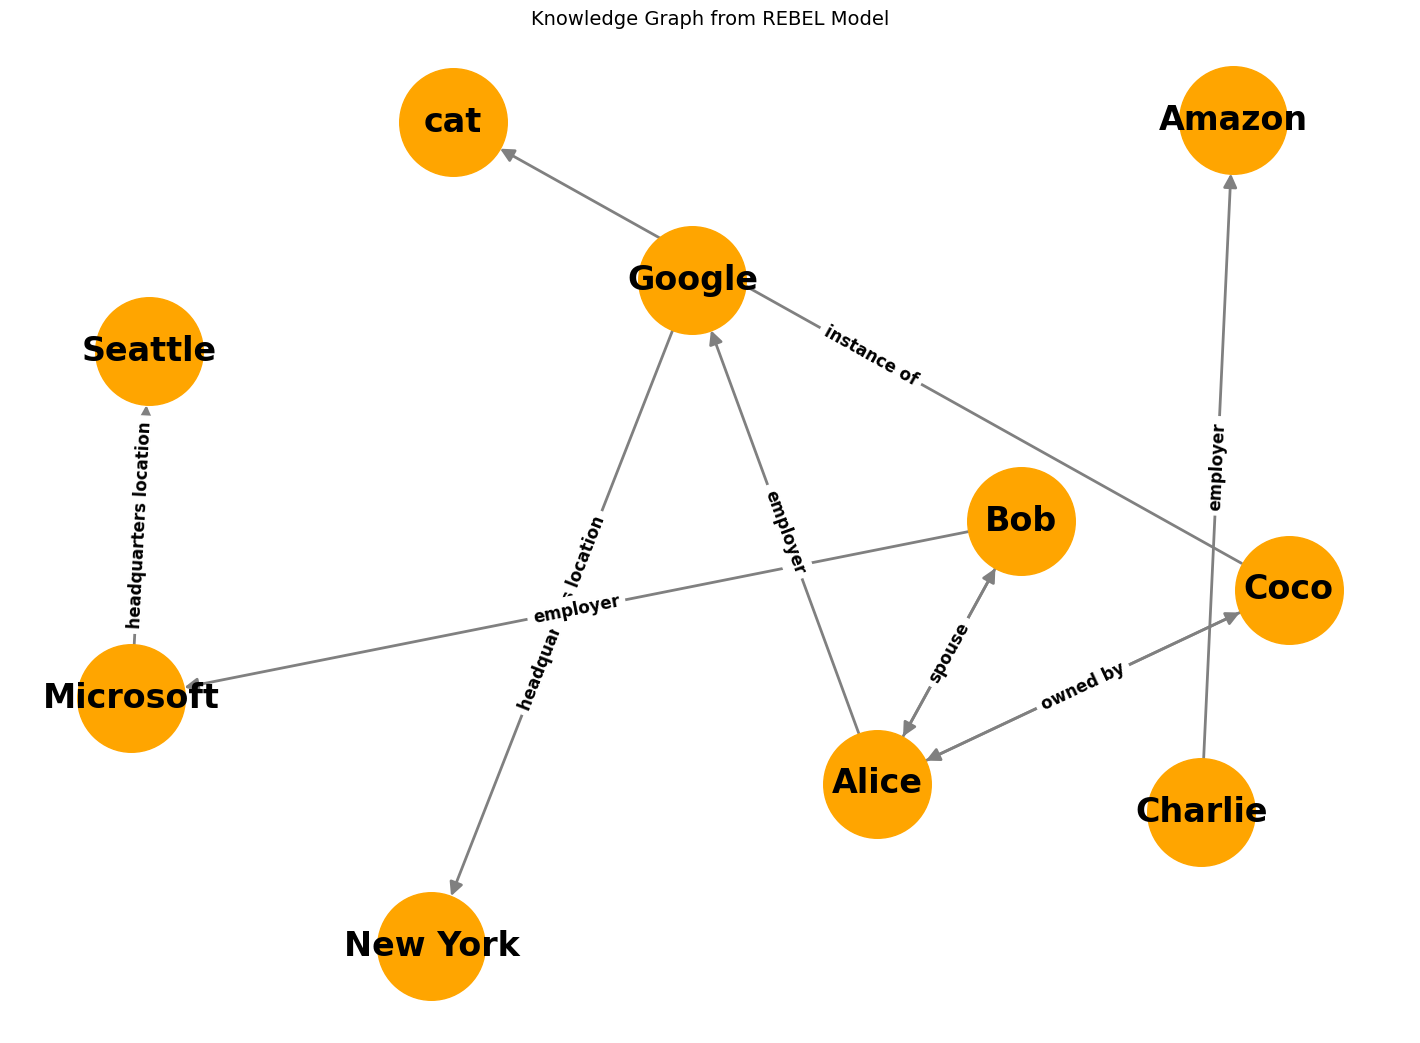

In [3]:
G = nx.DiGraph()
for s, p, o in triples:
    G.add_edge(s, o, relation=p)

print("\n그래프 구조:")
for node in G.nodes():
    neighbors = list(G.neighbors(node))
    if neighbors:
        print(f"  [{node}]")
        for neighbor in neighbors:
            rel = G[node][neighbor]['relation']
            print(f"    └─ {rel} → [{neighbor}]")

import matplotlib.pyplot as plt
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, k=2, iterations=50)
nx.draw(G, pos, with_labels=True, 
        node_color='orange', 
        node_size=6000, 
        font_size=24, 
        font_weight='bold', 
        arrows=True,
        arrowsize=20,
        edge_color='gray',
        width=2)
edge_labels = nx.get_edge_attributes(G, 'relation')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, 
                              font_color='black', 
                              font_size=12,
                              font_weight='bold')
plt.title("Knowledge Graph from REBEL Model", fontsize=14)
plt.tight_layout()
plt.show()
